In [2]:
!pip install yfinance



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.1 MB/s eta 0:00:00
  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 182.4 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.9-cp312-cp312-linux_x86_64.whl size=303802 sha256=4b974859d6ae68204745822f34dccfa5102b6a0880b094dd21065fdbb3d8d34b
  Stored in directory: /home/jupyterlab/.cache/pip/wheels/43/ef/2d/2c51d496bf084945ffdf838b4cc8767b8ba1cc20eb41588831
Successfully built peewee


In [3]:
import yfinance as yf

# Download Tesla stock data
tesla_data = yf.download('TSLA', start='2020-01-01', end='2021-12-31')

# Reset index to move date from index to column
tesla_data.reset_index(inplace=True)

# Display the first 5 rows
print(tesla_data.head())


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price        Date      Close       High        Low       Open     Volume
Ticker                  TSLA       TSLA       TSLA       TSLA       TSLA
0      2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
1      2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2      2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
3      2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
4      2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500


In [4]:
!pip install beautifulsoup4 requests pandas


In [8]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# URL for Tesla revenue data from Macrotrends
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"

# Add headers to pretend we are a regular browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36"
}

# Send GET request with headers
response = requests.get(url, headers=headers)

# Parse HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Find all tables
tables = soup.find_all('table')

# Check how many tables were found
print(f"Found {len(tables)} tables")

# Find the revenue table by scanning for a table with 'Revenue' in it
revenue_table = None

for table in tables:
    if 'Revenue' in table.text:
        revenue_table = table
        break

if revenue_table is None:
    raise Exception("Revenue table not found. Check if the website structure has changed or you were blocked.")

# Extract rows and data
rows = revenue_table.find_all('tr')
data = []
for row in rows[1:]:
    cols = row.find_all('td')
    cols = [col.text.strip() for col in cols]
    if len(cols) == 2:
        data.append(cols)

# Create DataFrame
tesla_revenue = pd.DataFrame(data, columns=['Date', 'Revenue'])

# Optional: Clean DataFrame
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

# Show last 5 rows
print(tesla_revenue.tail())


Found 6 tables
    Date Revenue
11  2013  $2,013
12  2012    $413
13  2011    $204
14  2010    $117
15  2009    $112


In [9]:
import yfinance as yf
import pandas as pd

# Extract GameStop (GME) stock data using yfinance
gme = yf.Ticker("GME")

# Get historical market data
gme_data = gme.history(period="max")

# Reset the index (moves the date index into a regular column)
gme_data.reset_index(inplace=True)

# Save to CSV (optional, if you need to submit a file for the assignment)
gme_data.to_csv("GME_Stock_Data.csv", index=False)

# Display the first 5 rows
print(gme_data.head())


                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683251  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [10]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# URL for GME revenue data from Macrotrends
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

# Send GET request
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Find the correct revenue table - Macrotrends usually uses the class "historical_data_table"
tables = soup.find_all('table')

# Identify the correct table by checking for 'Revenue'
revenue_table = None
for table in tables:
    if 'Revenue' in str(table):
        revenue_table = table
        break

if revenue_table is None:
    raise Exception("Revenue table not found. Check if the website structure has changed.")

# Extract rows and data
rows = revenue_table.find_all('tr')
data = []
for row in rows[1:]:
    cols = row.find_all('td')
    cols = [col.text.strip() for col in cols]
    if len(cols) == 2:  # Ensure it's a proper row with Date and Revenue
        data.append(cols)

# Create DataFrame
gme_revenue = pd.DataFrame(data, columns=['Date', 'Revenue'])

# Optional: Remove empty or placeholder revenue rows if necessary
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

# Display the last 5 rows (for your screenshot submission)
print(gme_revenue.tail())


Exception: Revenue table not found. Check if the website structure has changed.

In [11]:
import yfinance as yf

# Get stock data
gme = yf.Ticker("GME")

# Get financials, including revenue
gme_financials = gme.financials.T  # Transpose to have columns as dates
gme_revenue = gme.financials.loc['Total Revenue']

# Convert to DataFrame
gme_revenue_df = pd.DataFrame(gme_revenue).reset_index()
gme_revenue_df.columns = ['Date', 'Revenue']

# Display the last five rows
print(gme_revenue_df.tail())


        Date       Revenue
0 2024-01-31  5272800000.0
1 2023-01-31  5927200000.0
2 2022-01-31  6010700000.0
3 2021-01-31  5089800000.0


In [12]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# URL for GME revenue data from Macrotrends
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

# Send GET request
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Find the correct revenue table - Macrotrends usually uses the class "historical_data_table"
tables = soup.find_all('table')

# Identify the correct table by checking for 'Revenue'
revenue_table = None
for table in tables:
    if 'Revenue' in str(table):
        revenue_table = table
        break

if revenue_table is None:
    raise Exception("Revenue table not found. Check if the website structure has changed.")

# Extract rows and data
rows = revenue_table.find_all('tr')
data = []
for row in rows[1:]:
    cols = row.find_all('td')
    cols = [col.text.strip() for col in cols]
    if len(cols) == 2:  # Ensure it's a proper row with Date and Revenue
        data.append(cols)

# Create DataFrame
gme_revenue = pd.DataFrame(data, columns=['Date', 'Revenue'])

# Optional: Remove empty or placeholder revenue rows if necessary
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

# Display the last 5 rows (for your screenshot submission)
print(gme_revenue.tail())


Exception: Revenue table not found. Check if the website structure has changed.

In [13]:
import yfinance as yf

# Get stock data
gme = yf.Ticker("GME")

# Get financials, including revenue
gme_financials = gme.financials.T  # Transpose to have columns as dates
gme_revenue = gme.financials.loc['Total Revenue']

# Convert to DataFrame
gme_revenue_df = pd.DataFrame(gme_revenue).reset_index()
gme_revenue_df.columns = ['Date', 'Revenue']

# Display the last five rows
print(gme_revenue_df.tail())


        Date       Revenue
0 2024-01-31  5272800000.0
1 2023-01-31  5927200000.0
2 2022-01-31  6010700000.0
3 2021-01-31  5089800000.0


In [14]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download Tesla stock data
tesla_data = yf.download('TSLA', start='2015-01-01', end='2024-01-01')

# Reset index to have Date as a column
tesla_data.reset_index(inplace=True)

# Define the make_graph function
def make_graph(stock_data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(stock_data['Date'], stock_data['Close'], label='Closing Price', color='tab:blue')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function with Tesla data
make_graph(tesla_data, 'Tesla Stock Price Over Time')



ModuleNotFoundError: No module named 'matplotlib'

In [15]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 128.9 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed


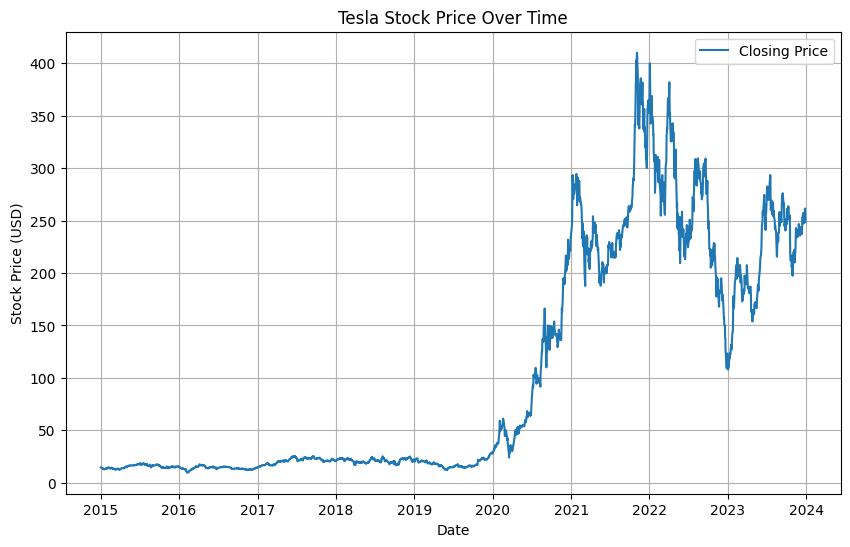

In [16]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download Tesla stock data
tesla_data = yf.download('TSLA', start='2015-01-01', end='2024-01-01')

# Reset index to have Date as a column
tesla_data.reset_index(inplace=True)

# Define the make_graph function
def make_graph(stock_data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(stock_data['Date'], stock_data['Close'], label='Closing Price', color='tab:blue')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function with Tesla data
make_graph(tesla_data, 'Tesla Stock Price Over Time')


[*********************100%***********************]  1 of 1 completed


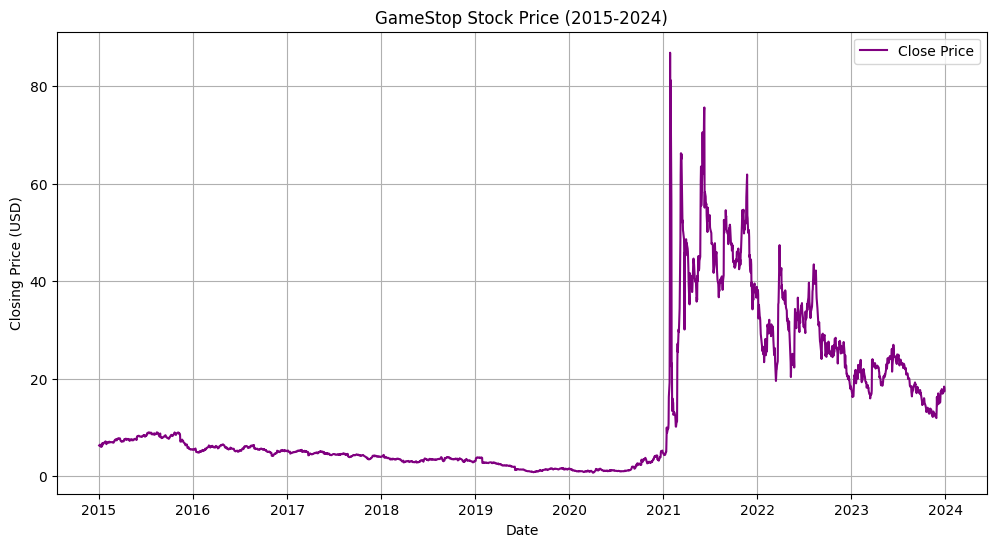

In [17]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download GameStop stock data
gme_data = yf.download('GME', start='2015-01-01', end='2024-01-01')

# Reset index to make Date a column
gme_data.reset_index(inplace=True)

# Define make_graph function
def make_graph(stock_data, title):
    plt.figure(figsize=(12,6))
    plt.plot(stock_data['Date'], stock_data['Close'], label='Close Price', color='purple')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the graph for GameStop
make_graph(gme_data, 'GameStop Stock Price (2015-2024)')
